YOLOvX Plate Detetion

Environment


In [ ]:
# İlgili data setleri Gogle Drive da ayrı ayrı açılan Plate Detection ve Plate Reading klasörlerinin içinde oluşturuldu

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%pwd

'/content'

In [3]:
%cd /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection

/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection


In [4]:
!pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 41.8/235.7 GB disk)


Test - Prediction

In [ ]:
# altta bir resimi model testi için kullanalım ()ünlü ultralytixs bus resimi- URL de verebilirdik)
# Sonuçları yanda veta Google Drive da bulaiblriz.

In [5]:
!yolo detect predict model=yolov8l.pt source="/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/bus.jpg"

Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv8l summary (fused): 112 layers, 43,668,288 parameters, 0 gradients, 165.2 GFLOPs

image 1/1 /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/bus.jpg: 640x480 5 persons, 1 bicycle, 1 bus, 53.0ms
Speed: 19.5ms preprocess, 53.0ms inference, 380.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs/detect/predict3
💡 Learn more at https://docs.ultralytics.com/modes/predict


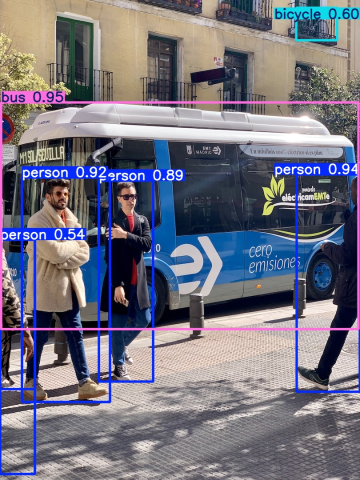

In [6]:
# prediction sonucunu burada resim olarak göruntuleyelim
import cv2
import imutils
from google.colab.patches import cv2_imshow

img_path= "/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/runs/detect/predict/bus.jpg"
img= cv2.imread(img_path)
img = imutils.resize(img, width=360) # aspect ratio
cv2_imshow(img)

Python Implementation

In [7]:
import cv2
import imutils
from ultralytics import YOLO
from google.colab.patches import cv2_imshow


0: 640x480 4 persons, 1 bus, 53.3ms
Speed: 7.4ms preprocess, 53.3ms inference, 145.7ms postprocess per image at shape (1, 3, 640, 480)


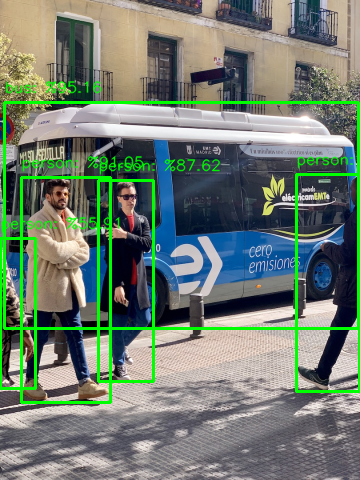

In [8]:
# Prediction üzerindeki kutuları manual olarak duzenleyelim

img_path= "/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/bus.jpg"
model_path= "/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/yolov8l.pt"

font= cv2.FONT_HERSHEY_SIMPLEX

model = YOLO(model_path)
img = cv2.imread(img_path)
img = imutils.resize(img, width=360) # aspect ratio

results = model(img)[0]

threshold = 0.5
for result in results.boxes.data.tolist():
  x1, y1, x2, y2, score, class_id = result
  x1, y1, x2, y2, class_id = int(x1), int(y1), int(x2), int(y2), int(class_id)
  if score > threshold:
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    class_name = results.names[class_id]
    score = score*100
    text = f"{class_name}: %{score:.2f}"

    cv2.putText(img, text, (x1, y1-10), font, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

cv2_imshow(img )


DataSEt

In [ ]:
#bunu 1 kez yapmak yeterli olacktır

# !unzip /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/plate_dataset.zip

In [ ]:
# data klasöründe bulunan config.yaml dosyasını düzenledik, özellikle dataset kısmını düzenledik

Train

In [10]:
!yolo detect train model=yolov8n.pt data="/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/config.yaml" epochs=100 patience=30 imgsz=640 workers=8 device=0 name=yolov8n-plate-detection

Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n-plate-detection10, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

Üstteki train işleminde** mAP:094** oranı elde ettik, hemde YOLO nano model ile..

Reults.png dosyasında sonuçların gayet iyi olduğıu görülüyor

In [ ]:
# Epoch işlemi yarıda kesilirse, kaldığı yerden devam etmesi için:
# !yolo detect train model="/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/runs/detect/yolov8l-plate-detection/weights/last.pt" resume=True

**Prediction Step**

Test klasörünü vereceğiz

In [13]:
!yolo detect predict model='/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/runs/detect/yolov8n-plate-detection10/weights/best.pt' source="/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/plate_dataset/images/test" save=True

Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/30 /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/plate_dataset/images/test/108.jpg: 416x640 1 plate, 54.6ms
image 2/30 /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/plate_dataset/images/test/130.jpg: 512x640 2 plates, 44.8ms
image 3/30 /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/plate_dataset/images/test/145.jpg: 480x640 2 plates, 45.3ms
image 4/30 /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/plate_dataset/images/test/151.jpg: 352x640 1 plate, 44.0ms
image 5/30 /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/plate_dataset/images/test/165.jpg: 384x640 1 plate, 43.9ms
image 6/30 /content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/plate_dataset/im

In [ ]:
# Ustte test klasöründeki (runs/detect/predict5) resimlere bakıldığında plakaları tandığı görulecektir.

Python Implementation - custom model

In [14]:
import cv2
import imutils
from ultralytics import YOLO
from google.colab.patches import cv2_imshow


0: 480x640 1 plate, 9.1ms
Speed: 2.2ms preprocess, 9.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


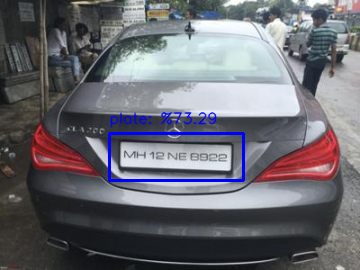

In [16]:
# Test klasörünü eğitimde görmediği için oradan bir resimi deneme için kullanalım
# model olarak eğitimdeki best.pt yi kullanaibliriz

img_path= "/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/data/plate_dataset/images/test/240.jpg"
model_path= "/content/drive/MyDrive/CNN-CV Lesson/Data Set and NB/Plate Detection/runs/detect/yolov8n-plate-detection10/weights/best.pt"

font= cv2.FONT_HERSHEY_SIMPLEX

model = YOLO(model_path)
img = cv2.imread(img_path)
img = imutils.resize(img, width=360) # aspect ratio

results = model(img)[0]

threshold = 0.5
for result in results.boxes.data.tolist():
  x1, y1, x2, y2, score, class_id = result
  x1, y1, x2, y2, class_id = int(x1), int(y1), int(x2), int(y2), int(class_id)
  if score > threshold:
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    class_name = results.names[class_id]
    score = score*100
    text = f"{class_name}: %{score:.2f}"

    cv2.putText(img, text, (x1, y1-10), font, 0.5, (255,0, 0), 1, cv2.LINE_AA)

cv2_imshow(img )

In [ ]:
# Plaka alanını başarılı b,ir şekilde bounding box ile göstermektedir.